<a href="https://colab.research.google.com/github/Matheusbcy/-Data-Science-IA-/blob/main/Previs%C3%A3o_de_vendas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

## Dados das vendas

In [3]:
selas_train_df = pd.read_csv("/content/train.csv")

In [4]:
selas_train_df.shape

(1017209, 9)

In [5]:
selas_train_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [6]:
selas_train_df["DayOfWeek"].unique()

array([5, 4, 3, 2, 1, 7, 6])

In [7]:
selas_train_df["Open"].unique()

array([1, 0])

In [8]:
selas_train_df["Promo"].unique()

array([1, 0])

In [9]:
selas_train_df["StateHoliday"].unique()

array(['0', 'a', 'b', 'c', 0], dtype=object)

In [10]:
selas_train_df["SchoolHoliday"].unique()

array([1, 0])

In [11]:
selas_train_df.tail()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1
1017208,1115,2,2013-01-01,0,0,0,0,a,1


In [12]:
selas_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [13]:
selas_train_df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


## Dados das lojas

In [14]:
store_info_df = pd.read_csv("/content/store.csv")
store_info_df.shape

(1115, 10)

In [15]:
store_info_df.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [16]:
store_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [17]:
store_info_df.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


# Exploração dos dados

## Dados das vendas

<Axes: >

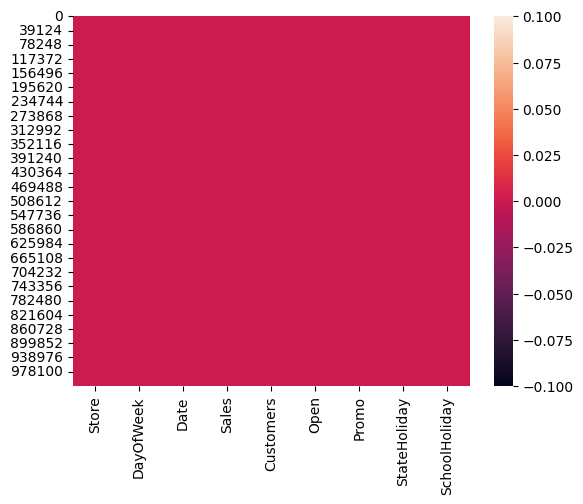

In [18]:
sns.heatmap(selas_train_df.isnull())

In [19]:
selas_train_df.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0


array([[<Axes: title={'center': 'Store'}>,
        <Axes: title={'center': 'DayOfWeek'}>,
        <Axes: title={'center': 'Sales'}>],
       [<Axes: title={'center': 'Customers'}>,
        <Axes: title={'center': 'Open'}>,
        <Axes: title={'center': 'Promo'}>],
       [<Axes: title={'center': 'SchoolHoliday'}>, <Axes: >, <Axes: >]],
      dtype=object)

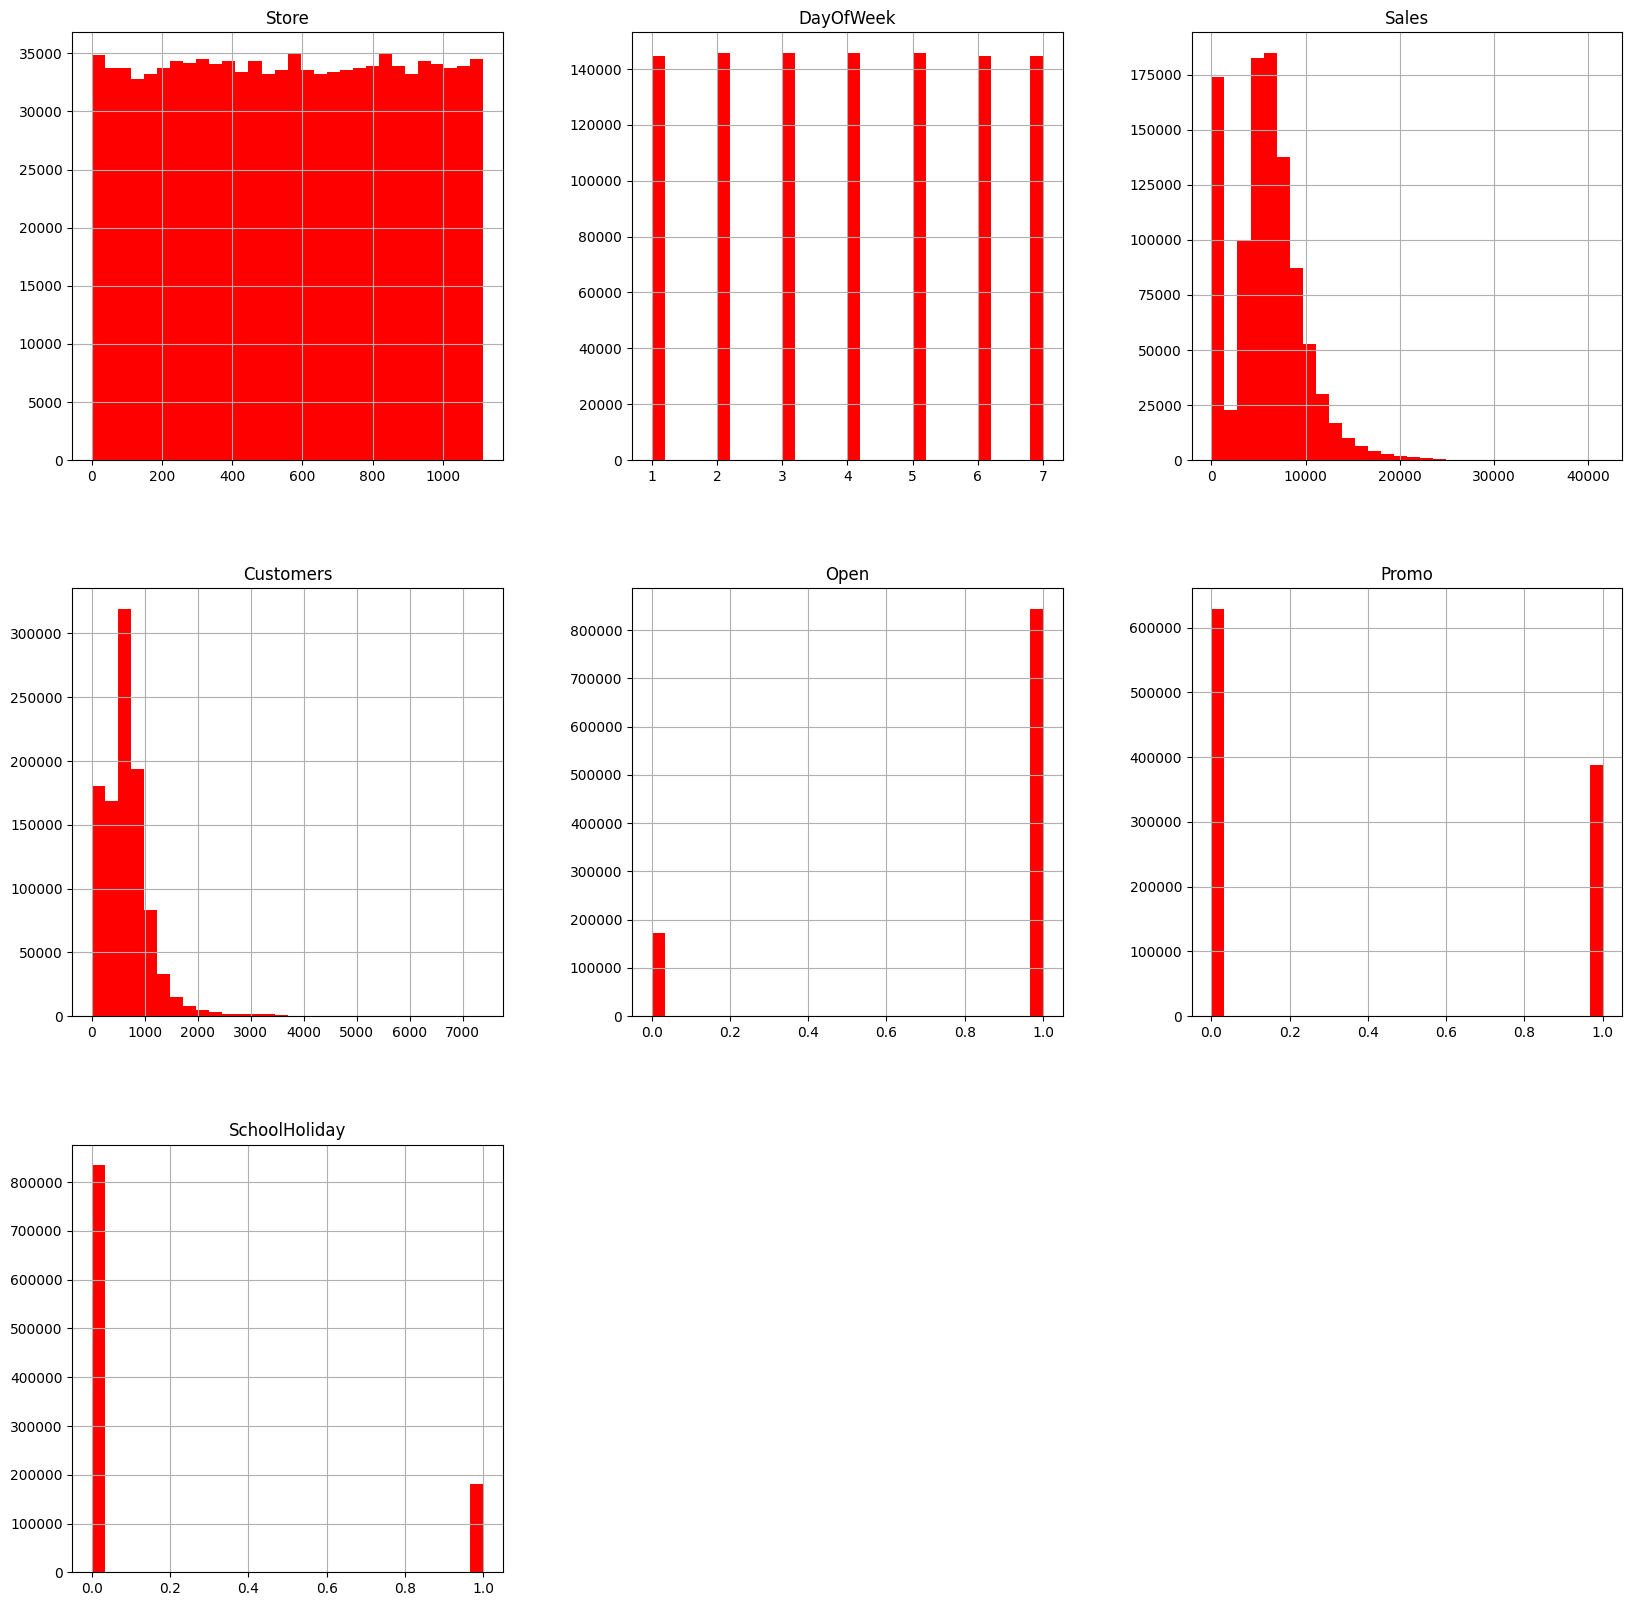

In [20]:
selas_train_df.hist(bins = 30, figsize = (20,20), color = "r")

In [21]:
selas_train_df["Customers"].max()

7388

In [22]:
closed_trains_df = selas_train_df[selas_train_df["Open"] == 0]
open_trains_df = selas_train_df[selas_train_df["Open"] == 1]

In [23]:
closed_trains_df.shape, open_trains_df.shape

((172817, 9), (844392, 9))

In [24]:
print("Total = ", len(selas_train_df))
print(f"Número de lojas-dias fechado = {len(closed_trains_df)}")
print(f"Número de lojas-dias aberto = {len(open_trains_df)}")

Total =  1017209
Número de lojas-dias fechado = 172817
Número de lojas-dias aberto = 844392


In [25]:
closed_trains_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
291,292,5,2015-07-31,0,0,0,1,0,1
875,876,5,2015-07-31,0,0,0,1,0,1
1406,292,4,2015-07-30,0,0,0,1,0,1
1990,876,4,2015-07-30,0,0,0,1,0,1
2521,292,3,2015-07-29,0,0,0,1,0,1


In [26]:
sales_train_df = selas_train_df[selas_train_df["Open"] == 1]

In [27]:
sales_train_df.drop(labels = ["Open"], axis = 1, inplace = True)

In [28]:
sales_train_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,0,1
1,2,5,2015-07-31,6064,625,1,0,1
2,3,5,2015-07-31,8314,821,1,0,1
3,4,5,2015-07-31,13995,1498,1,0,1
4,5,5,2015-07-31,4822,559,1,0,1


In [29]:
sales_train_df.describe()

,Store,DayOfWeek,Sales,Customers,Promo,SchoolHoliday
count,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000
mean,558.422920,3.520361,6955.514291,762.728395,0.446352,0.193580
std,321.731914,1.723689,3104.214680,401.227674,0.497114,0.395103
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,280.000000,2.000000,4859.000000,519.000000,0.000000,0.000000
50%,558.000000,3.000000,6369.000000,676.000000,0.000000,0.000000
75%,837.000000,5.000000,8360.000000,893.000000,1.000000,0.000000
max,1115.000000,7.000000,41551.000000,7388.000000,1.000000,1.000000


## Dados da lojas

<Axes: >

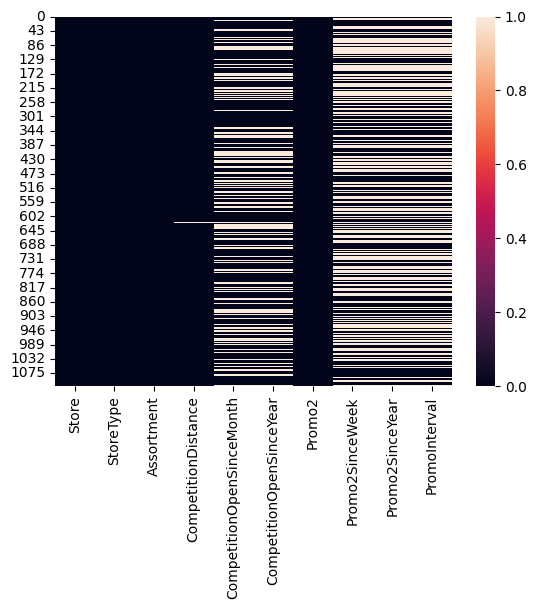

In [30]:
sns.heatmap(store_info_df.isnull())

In [31]:
store_info_df[store_info_df["CompetitionDistance"].isnull()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


In [32]:
store_info_df[store_info_df["CompetitionOpenSinceMonth"].isnull()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
11,12,a,c,1070.0,NaN,NaN,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
12,13,d,a,310.0,NaN,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov"
15,16,a,c,3270.0,NaN,NaN,0,NaN,NaN,NaN
18,19,a,c,3240.0,NaN,NaN,1,22.0,2011.0,"Mar,Jun,Sept,Dec"
21,22,a,a,1040.0,NaN,NaN,1,22.0,2012.0,"Jan,Apr,Jul,Oct"
...,...,...,...,...,...,...,...,...,...,...
1095,1096,a,c,1130.0,NaN,NaN,1,10.0,2014.0,"Mar,Jun,Sept,Dec"
1099,1100,a,a,540.0,NaN,NaN,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [33]:
store_info_df[store_info_df["CompetitionOpenSinceYear"].isnull()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
11,12,a,c,1070.0,NaN,NaN,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
12,13,d,a,310.0,NaN,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov"
15,16,a,c,3270.0,NaN,NaN,0,NaN,NaN,NaN
18,19,a,c,3240.0,NaN,NaN,1,22.0,2011.0,"Mar,Jun,Sept,Dec"
21,22,a,a,1040.0,NaN,NaN,1,22.0,2012.0,"Jan,Apr,Jul,Oct"
...,...,...,...,...,...,...,...,...,...,...
1095,1096,a,c,1130.0,NaN,NaN,1,10.0,2014.0,"Mar,Jun,Sept,Dec"
1099,1100,a,a,540.0,NaN,NaN,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [34]:
store_info_df[store_info_df["Promo2"] == 0]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1107,1108,a,a,540.0,4.0,2004.0,0,NaN,NaN,NaN
1109,1110,c,c,900.0,9.0,2010.0,0,NaN,NaN,NaN
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN


In [35]:
str_cols = ["Promo2SinceWeek", "Promo2SinceYear", "PromoInterval", "CompetitionOpenSinceYear", "CompetitionOpenSinceMonth"]

for str in str_cols:
  store_info_df[str].fillna(0, inplace = True)

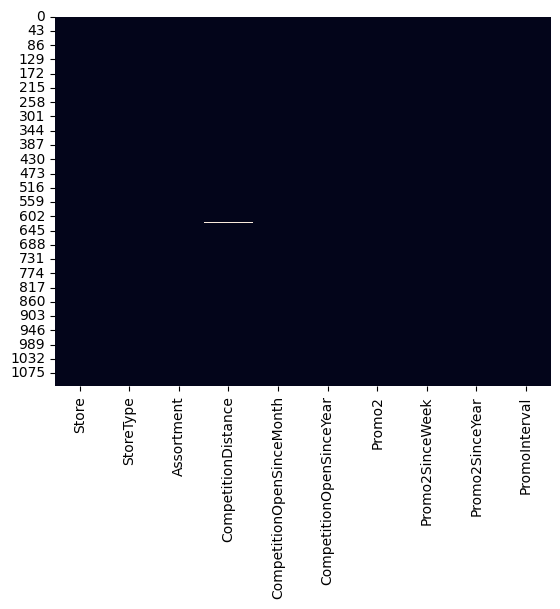

In [36]:
sns.heatmap(store_info_df.isnull(), cbar = False);

In [37]:
store_info_df["CompetitionDistance"].fillna(store_info_df["CompetitionDistance"].mean(), inplace = True)

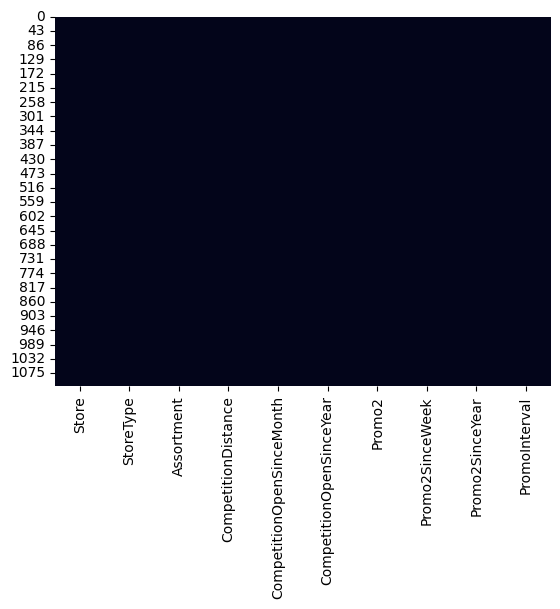

In [38]:
sns.heatmap(store_info_df.isnull(), cbar = False);

array([[<Axes: title={'center': 'Store'}>,
        <Axes: title={'center': 'CompetitionDistance'}>,
        <Axes: title={'center': 'CompetitionOpenSinceMonth'}>],
       [<Axes: title={'center': 'CompetitionOpenSinceYear'}>,
        <Axes: title={'center': 'Promo2'}>,
        <Axes: title={'center': 'Promo2SinceWeek'}>],
       [<Axes: title={'center': 'Promo2SinceYear'}>, <Axes: >, <Axes: >]],
      dtype=object)

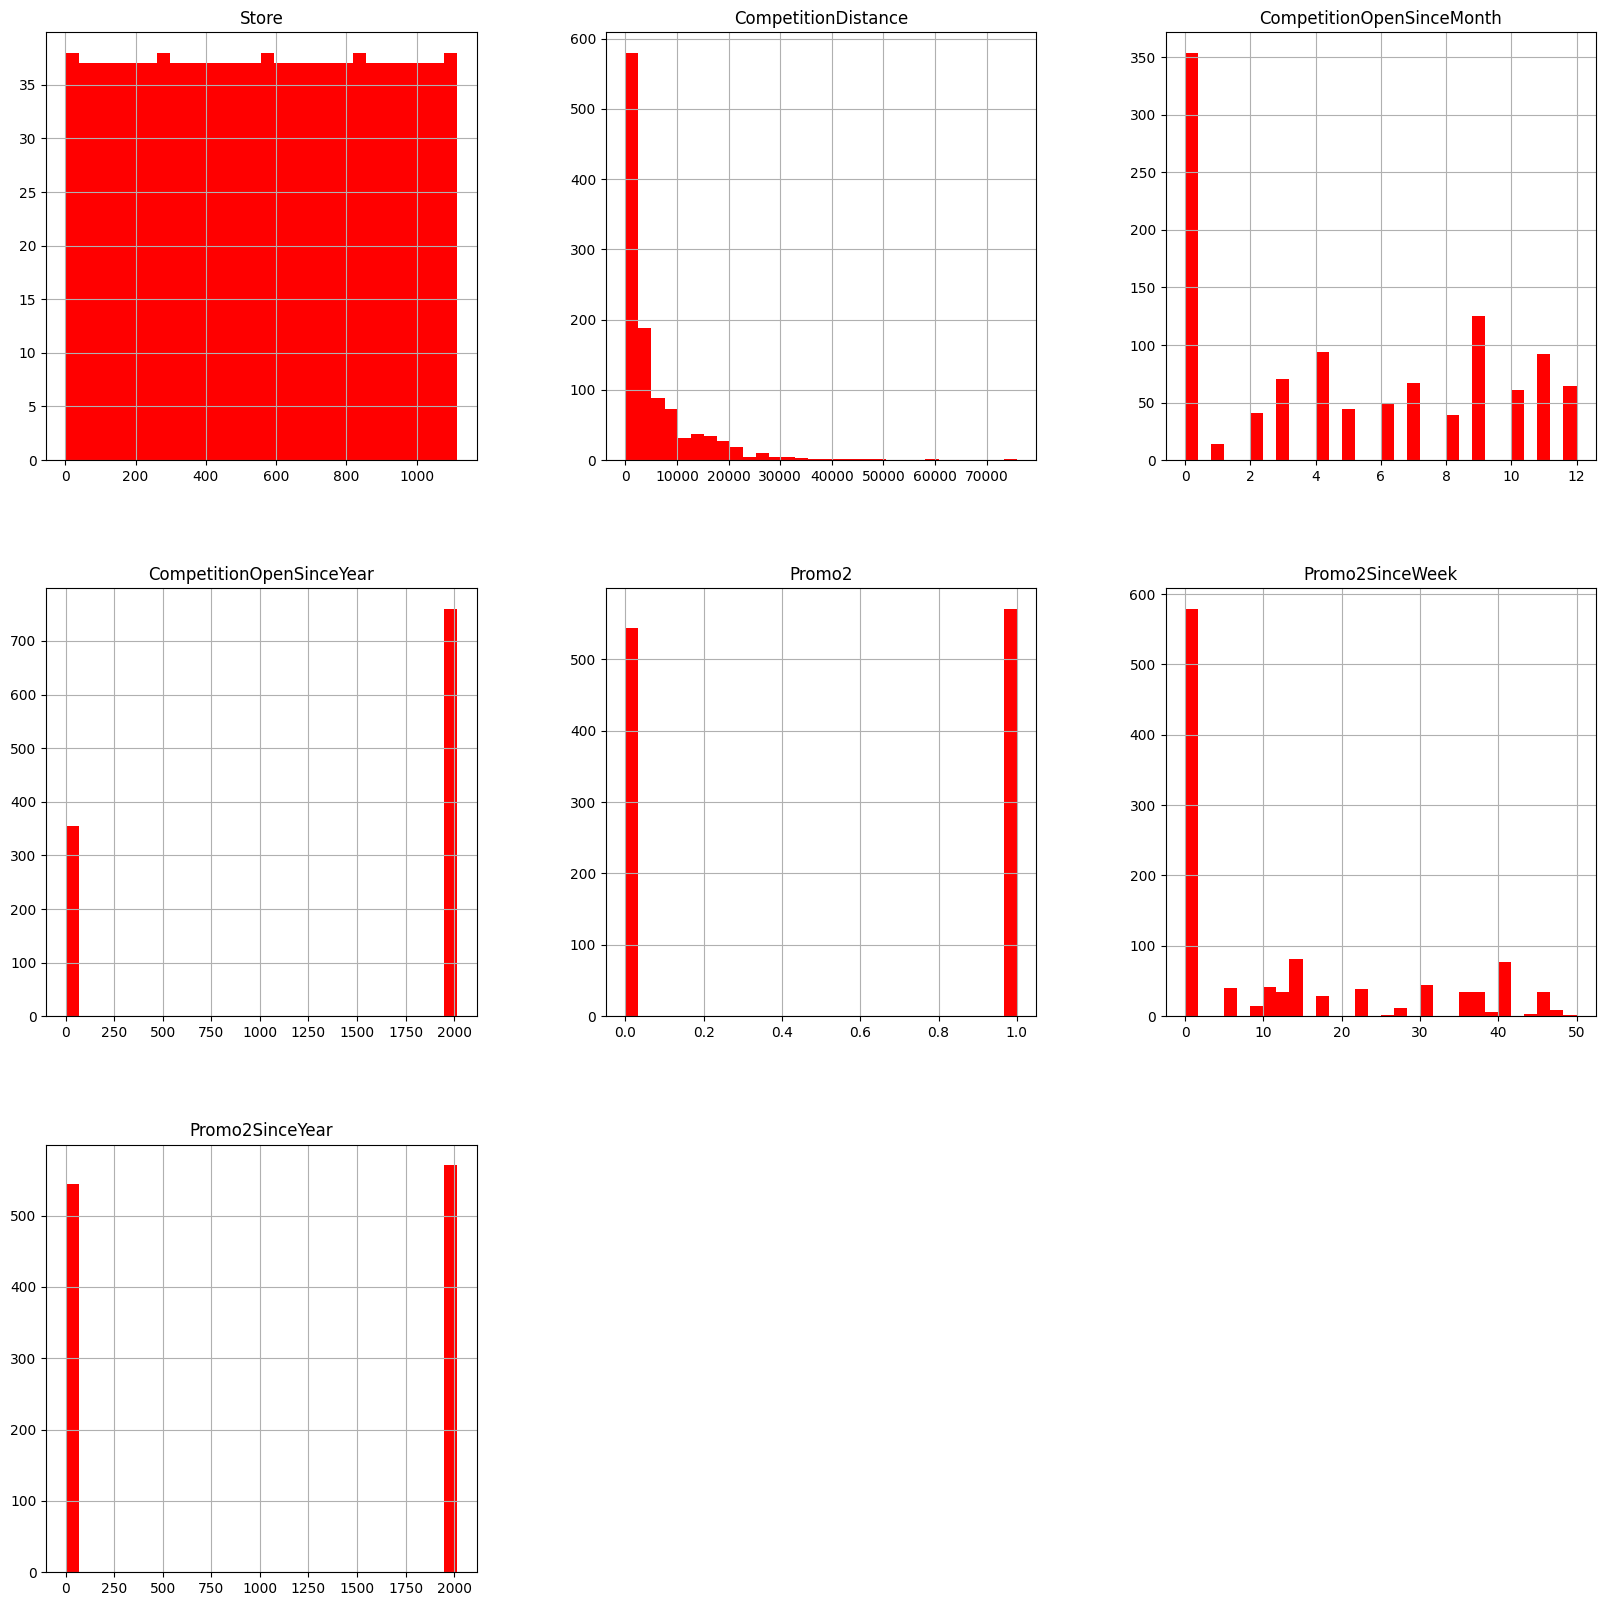

In [39]:
store_info_df.hist(bins = 30, figsize = (20, 20), color = "r")

## Dados unidos (vendas + lojas)

In [40]:
sales_train_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,0,1
1,2,5,2015-07-31,6064,625,1,0,1
2,3,5,2015-07-31,8314,821,1,0,1
3,4,5,2015-07-31,13995,1498,1,0,1
4,5,5,2015-07-31,4822,559,1,0,1


In [41]:
store_info_df.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,0.0,0.0,0
4,5,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0


In [42]:
sales_train_all_df = pd.merge(sales_train_df, store_info_df, how = "inner", on = "Store")

In [43]:
sales_train_all_df.shape

(844392, 17)

In [44]:
sales_train_all_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,2,5,2015-07-31,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,0
4,5,5,2015-07-31,4822,559,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0


<Axes: >

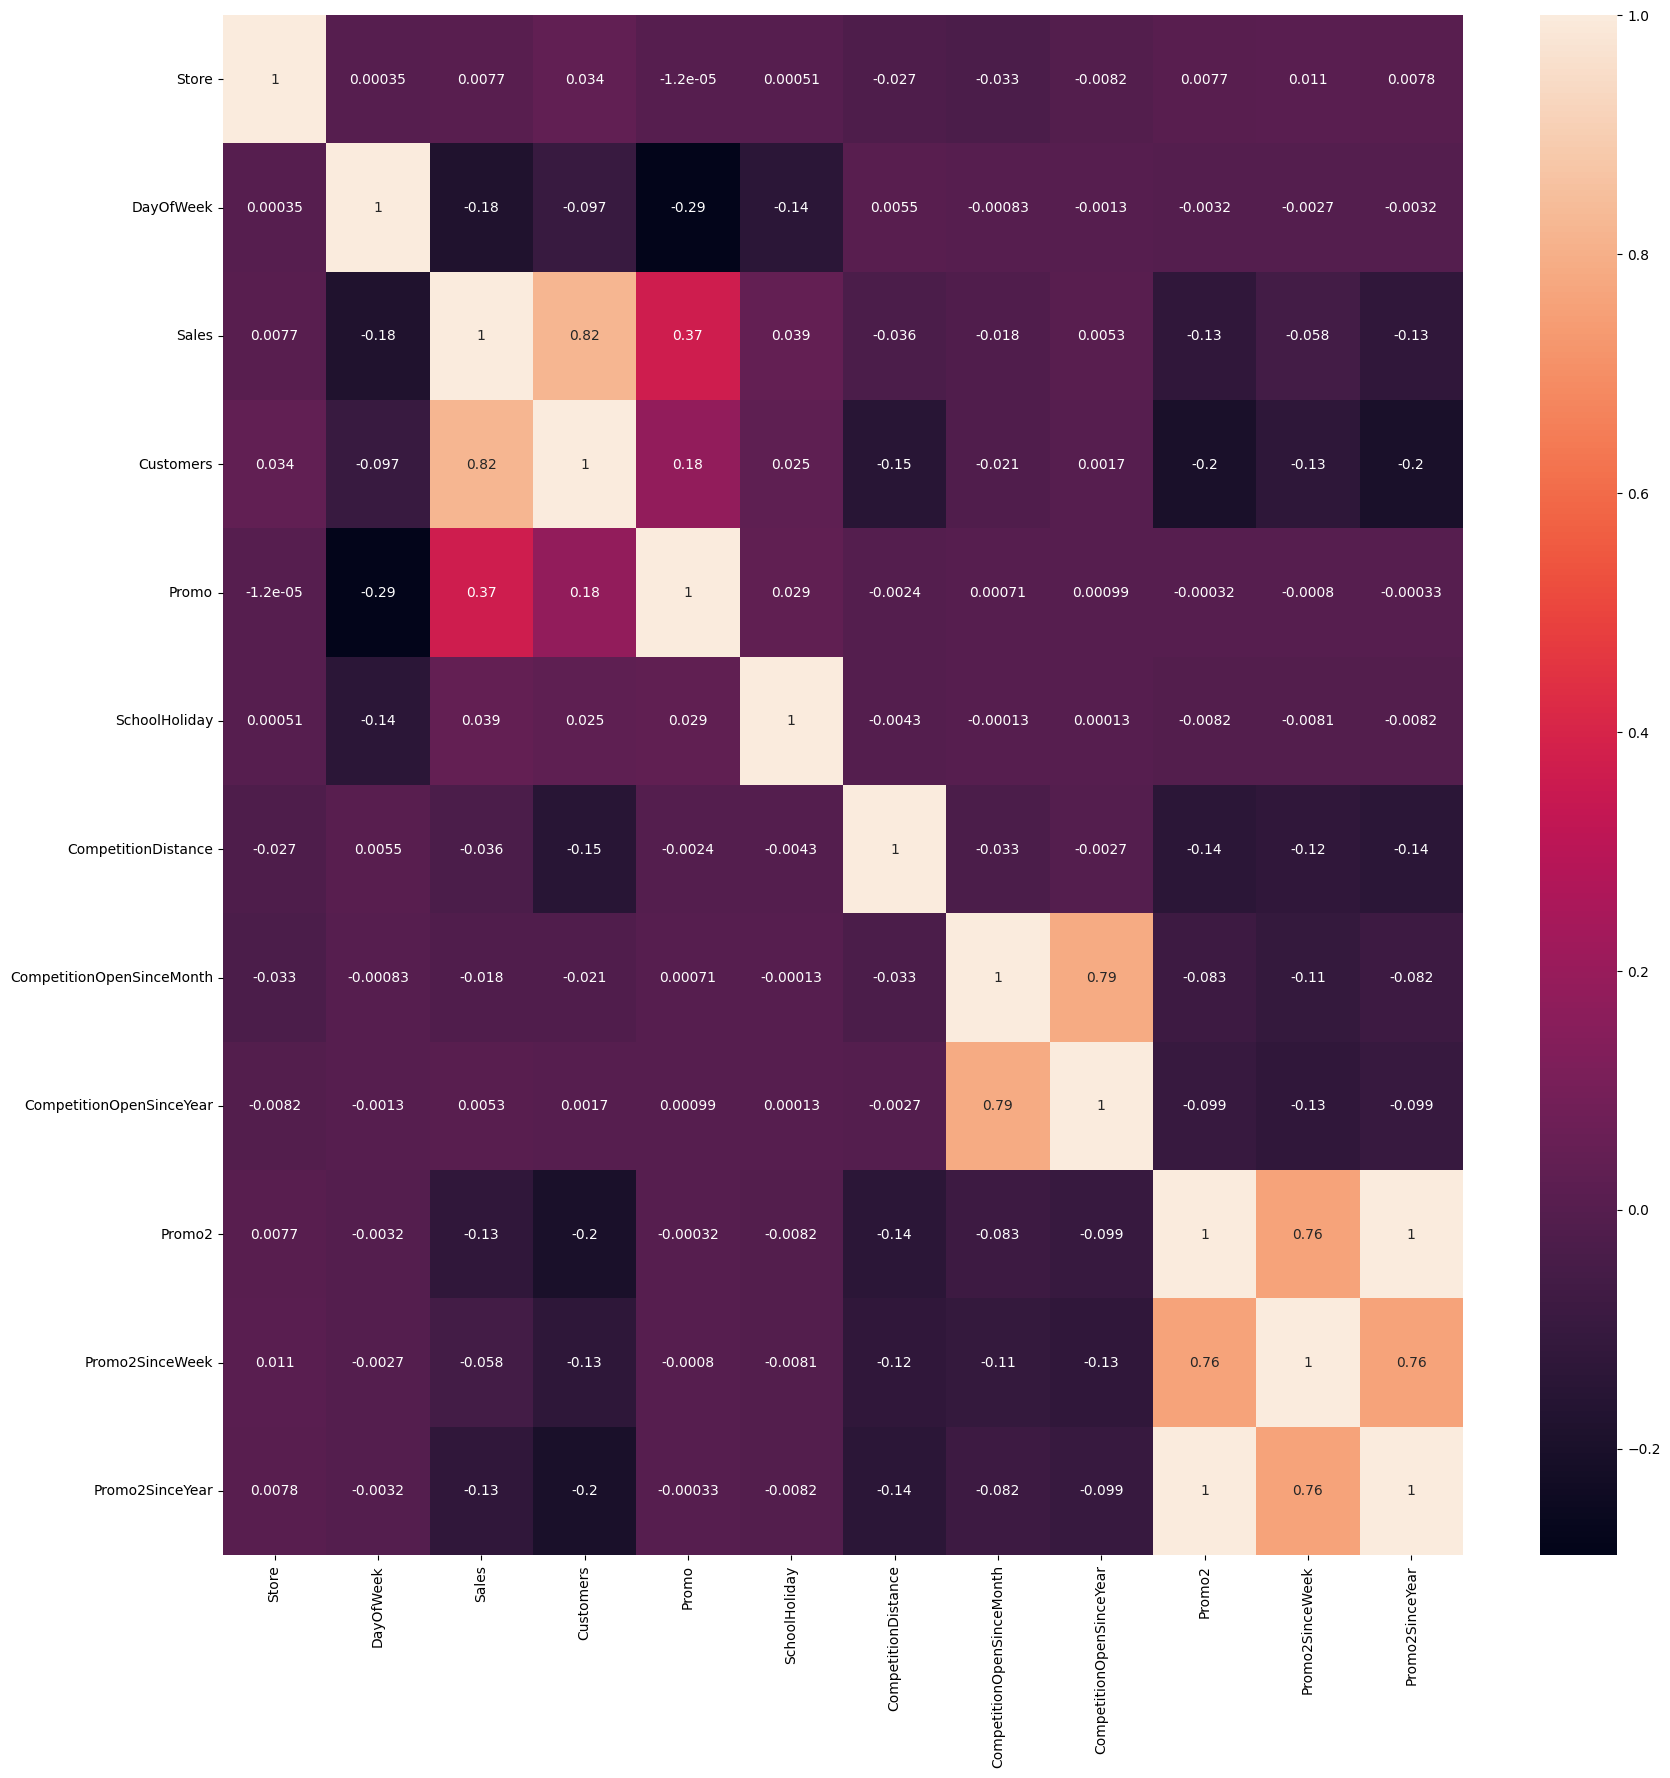

In [45]:
correlations = sales_train_all_df.select_dtypes(include=['float64', 'int64']).corr()

f, ax = plt.subplots(figsize = (20, 20))
sns.heatmap(correlations, annot = True)

In [46]:
correlations = sales_train_all_df.select_dtypes(include=['float64', 'int64']).corr()["Sales"].sort_values()
correlations

,Sales
DayOfWeek,-0.178736
Promo2SinceYear,-0.127621
Promo2,-0.127596
Promo2SinceWeek,-0.058476
CompetitionDistance,-0.036343
CompetitionOpenSinceMonth,-0.018370
CompetitionOpenSinceYear,0.005266
Store,0.007710
SchoolHoliday,0.038617
Promo,0.368145


In [47]:
sales_train_all_df["Year"] = pd.DatetimeIndex(sales_train_all_df["Date"]).year

In [48]:
sales_train_all_df["Month"] = pd.DatetimeIndex(sales_train_all_df["Date"]).month

In [49]:
sales_train_all_df["Day"] = pd.DatetimeIndex(sales_train_all_df["Date"]).day

In [50]:
sales_train_all_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015,7,31
1,2,5,2015-07-31,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31
2,3,5,2015-07-31,8314,821,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31
3,4,5,2015-07-31,13995,1498,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,0,2015,7,31
4,5,5,2015-07-31,4822,559,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0,2015,7,31


Text(0.5, 1.0, 'Média de vendas por mês')

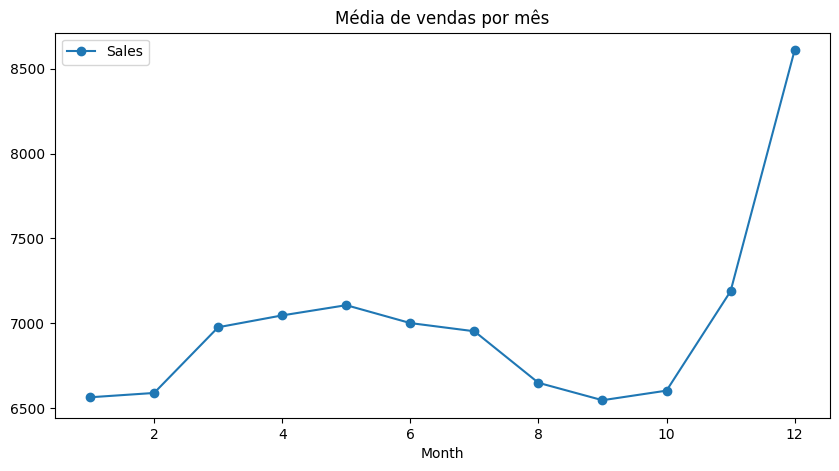

In [51]:
axis = sales_train_all_df.groupby("Month")[["Sales"]].mean().plot(figsize = (10, 5), marker = "o")
axis.set_title("Média de vendas por mês")

Text(0.5, 1.0, 'Média de clientes por mês')

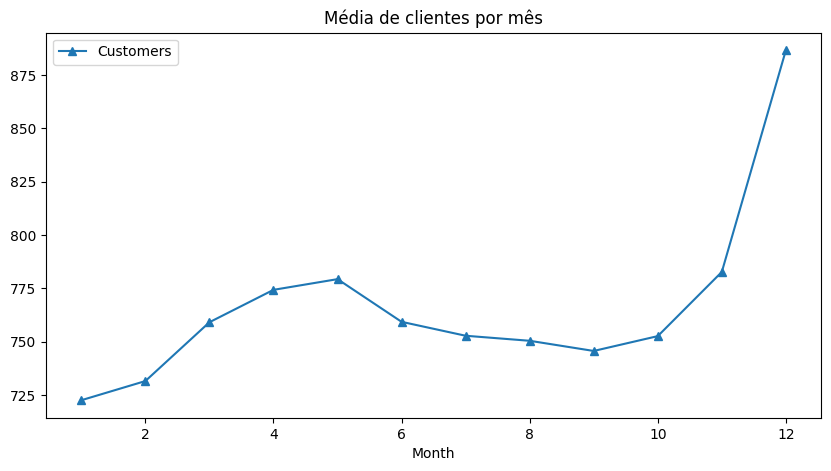

In [52]:
axis = sales_train_all_df.groupby("Month")[["Customers"]].mean().plot(figsize = (10, 5), marker = "^")
axis.set_title("Média de clientes por mês")

Text(0.5, 1.0, 'Média de vendas por dia')

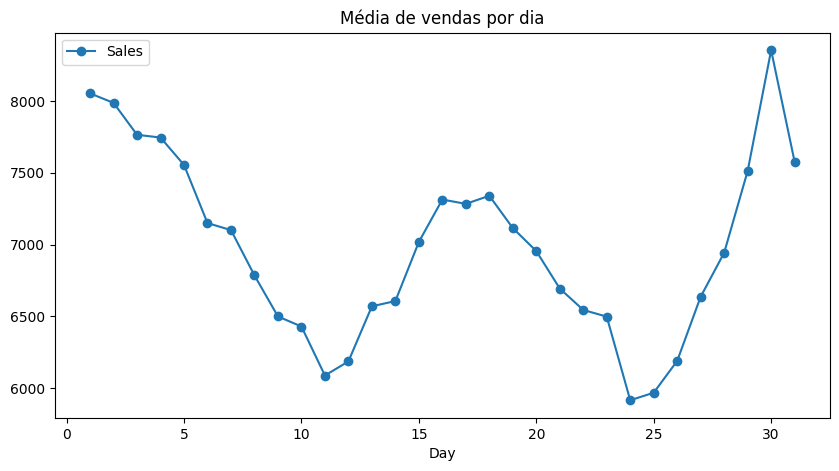

In [53]:
axis = sales_train_all_df.groupby("Day")[["Sales"]].mean().plot(figsize = (10, 5), marker = "o")
axis.set_title("Média de vendas por dia")

Text(0.5, 1.0, 'Média de clientes por dia')

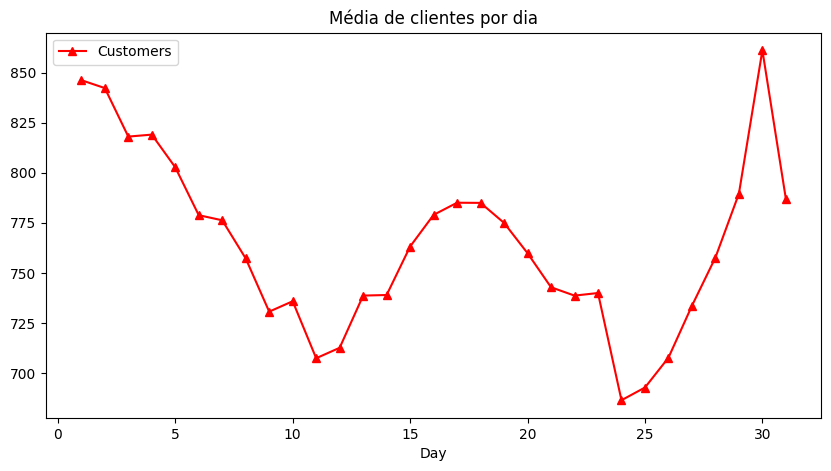

In [54]:
axis = sales_train_all_df.groupby("Day")[["Customers"]].mean().plot(figsize = (10, 5), marker = "^", color = "r")
axis.set_title("Média de clientes por dia")

Text(0.5, 1.0, 'Média de vendas por dia da semana')

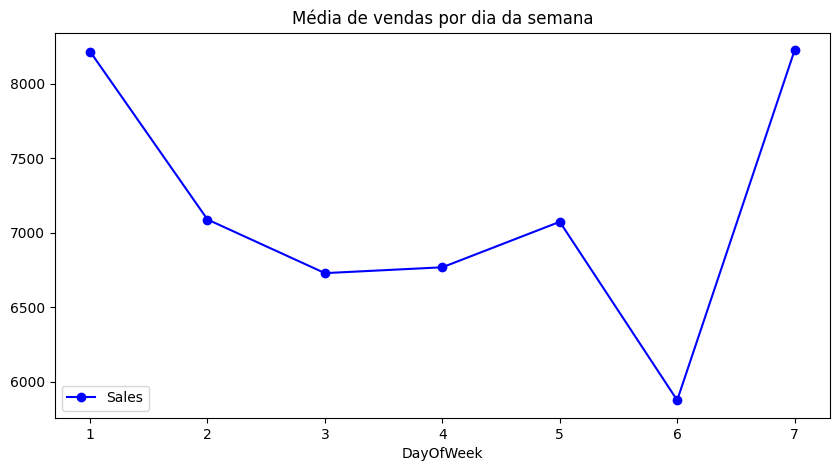

In [55]:
axis = sales_train_all_df.groupby("DayOfWeek")[["Sales"]].mean().plot(figsize = (10, 5), marker = "o", color = "b")
axis.set_title("Média de vendas por dia da semana")

Text(0.5, 1.0, 'Média de clientes por dia da semana')

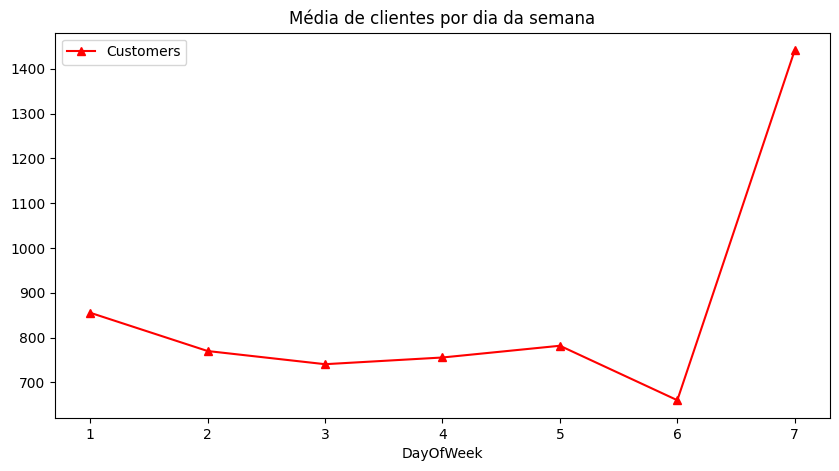

In [56]:
axis = sales_train_all_df.groupby("DayOfWeek")[["Customers"]].mean().plot(figsize = (10, 5), marker = "^", color = "r")
axis.set_title("Média de clientes por dia da semana")

<Axes: xlabel='Date'>

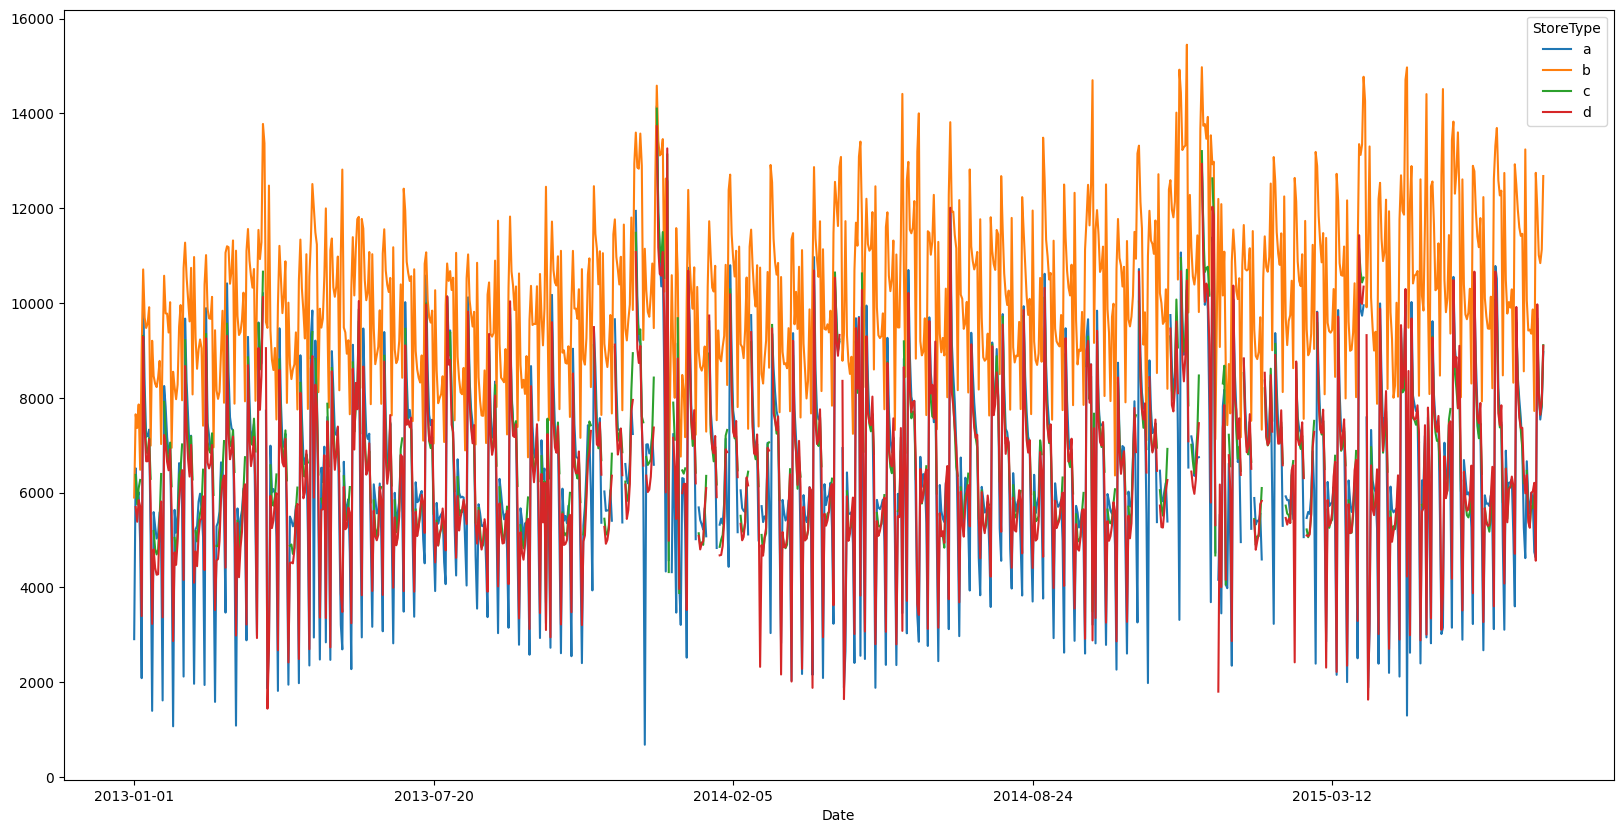

In [57]:
fig, ax = plt.subplots(figsize = (20, 10))
sales_train_all_df.groupby(["Date", "StoreType"])["Sales"].mean().unstack().plot(ax = ax)

## Treinamento do modelo - Parte 1

In [ ]:
!pip install prophet

In [59]:
from prophet import Prophet

In [60]:
def sales_prediction(store_id, sales_df, periods):
  sales_df = sales_df[sales_df["Store"] == store_id]
  sales_df = sales_df[["Date", "Sales"]].rename(columns = {"Date": "ds", "Sales": "y"})

  sales_df = sales_df.sort_values(by = "ds")

  model = Prophet()
  model.fit(sales_df)
  future = model.make_future_dataframe(periods = periods)
  forecast = model.predict(future)
  figure1 = model.plot(forecast, xlabel = "Data", ylabel = "Vendas");
  figure2 = model.plot_components(forecast);
  return sales_df, forecast

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpeewsv45w/m4xfugk1.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpeewsv45w/32lwidu0.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=93597', 'data', 'file=/tmp/tmpeewsv45w/m4xfugk1.json', 'init=/tmp/tmpeewsv45w/32lwidu0.json', 'output', 'file=/tmp/tmpeewsv45w/prophet_model0uhd0ai9/prophet_model-20250911175635.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
17:56:35 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
17:56:35 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


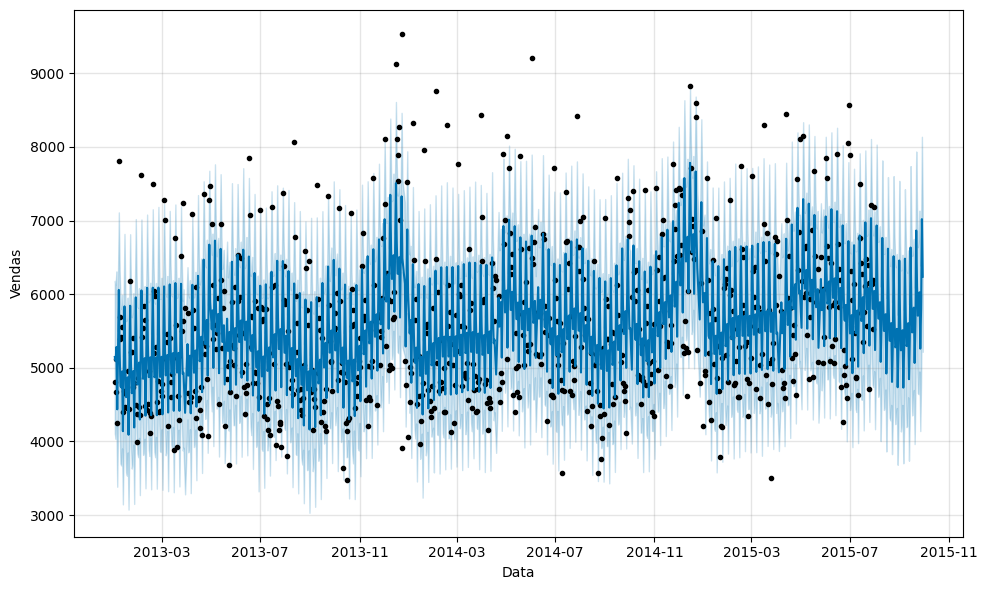

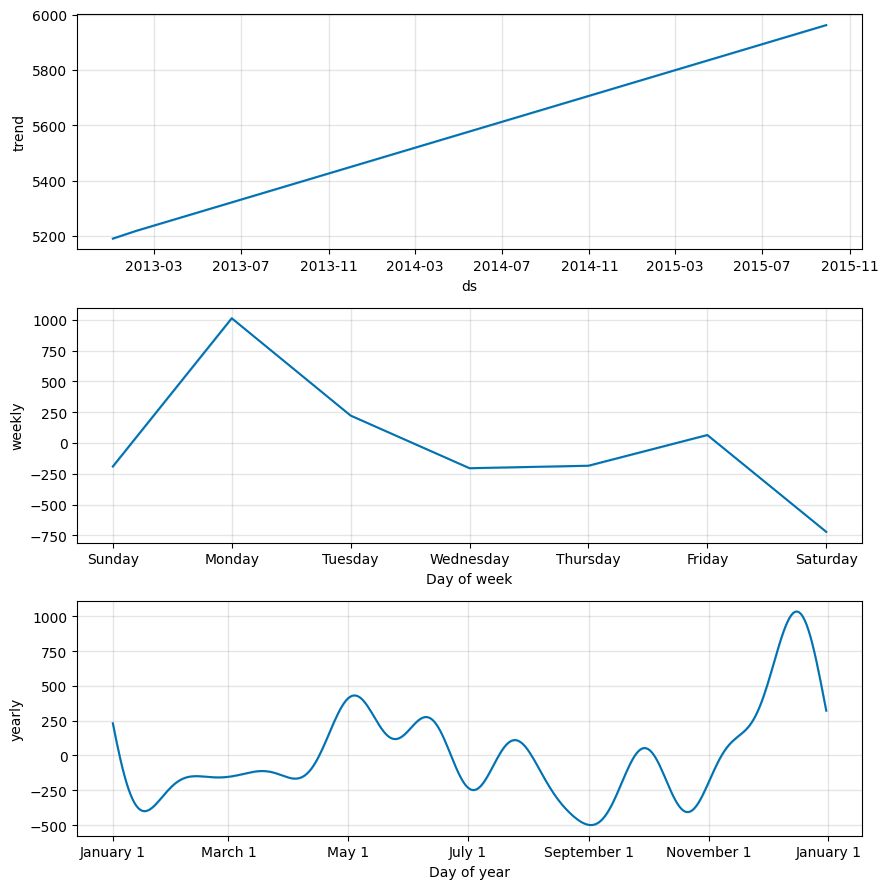

In [61]:
df_origin, df_prediction = sales_prediction(10, sales_train_all_df, 60)

In [62]:
df_origin.shape, df_prediction.shape

((784, 2), (844, 19))

In [63]:
df_prediction.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
839,2015-09-25,5958.787574,4950.741246,7135.328001,5958.564032,5958.985049,66.985029,66.985029,66.985029,64.871229,64.871229,64.871229,2.113800,2.113800,2.113800,0.0,0.0,0.0,6025.772603
840,2015-09-26,5959.555956,4141.055972,6388.598001,5959.326178,5959.760628,-699.522319,-699.522319,-699.522319,-720.328073,-720.328073,-720.328073,20.805755,20.805755,20.805755,0.0,0.0,0.0,5260.033637
841,2015-09-27,5960.324337,4797.956120,6886.566017,5960.088978,5960.535283,-154.758994,-154.758994,-154.758994,-190.330875,-190.330875,-190.330875,35.571882,35.571882,35.571882,0.0,0.0,0.0,5805.565344
842,2015-09-28,5961.092719,5989.414431,8137.478936,5960.847110,5961.309823,1057.952702,1057.952702,1057.952702,1011.846434,1011.846434,1011.846434,46.106268,46.106268,46.106268,0.0,0.0,0.0,7019.045421
843,2015-09-29,5961.861101,5218.841901,7200.967263,5961.608214,5962.085556,274.635832,274.635832,274.635832,222.454534,222.454534,222.454534,52.181298,52.181298,52.181298,0.0,0.0,0.0,6236.496933


In [64]:
df_prediction.tail(60).to_csv("previsoes_vendas.csv")

## Treinamento parte 2 - adicionando feriados

In [65]:
def sales_prediction(store_id, sales_df, holidays, periods):
  sales_df = sales_df[sales_df["Store"] == store_id]
  sales_df = sales_df[["Date", "Sales"]].rename(columns = {"Date": "ds", "Sales": "y"})

  sales_df = sales_df.sort_values(by = "ds")

  model = Prophet(holidays = holidays)
  model.fit(sales_df)
  future = model.make_future_dataframe(periods = periods)
  forecast = model.predict(future)
  figure1 = model.plot(forecast, xlabel = "Data", ylabel = "Vendas");
  figure2 = model.plot_components(forecast);
  return sales_df, forecast

In [66]:
school_holidays = sales_train_all_df[sales_train_all_df["SchoolHoliday"] == 1].loc[:, "Date"].values
school_holidays.shape

(163457,)

In [67]:
len(np.unique(school_holidays))

477

In [68]:
state_holidays = sales_train_all_df[(sales_train_all_df["StateHoliday"] == "a") | (sales_train_all_df["StateHoliday"] == "b") | (sales_train_all_df["StateHoliday"] == "c")].loc[:, "Date"].values

In [69]:
state_holidays.shape

(910,)

In [70]:
len(np.unique(state_holidays))

35

In [71]:
state_holidays = pd.DataFrame({"ds": pd.to_datetime(state_holidays), "holiday": "state_holiday"})

In [72]:
state_holidays

,ds,holiday
0,2015-06-04,state_holiday
1,2015-06-04,state_holiday
2,2015-06-04,state_holiday
3,2015-06-04,state_holiday
4,2015-06-04,state_holiday
...,...,...
905,2013-01-01,state_holiday
906,2013-01-01,state_holiday
907,2013-01-01,state_holiday
908,2013-01-01,state_holiday


In [73]:
school_holidays = pd.DataFrame({"ds": pd.to_datetime(school_holidays), "holiday": "school_holiday"})
school_holidays

,ds,holiday
0,2015-07-31,school_holiday
1,2015-07-31,school_holiday
2,2015-07-31,school_holiday
3,2015-07-31,school_holiday
4,2015-07-31,school_holiday
...,...,...
163452,2013-01-01,school_holiday
163453,2013-01-01,school_holiday
163454,2013-01-01,school_holiday
163455,2013-01-01,school_holiday


In [74]:
school_state_holidays = pd.concat((state_holidays, school_holidays))
school_state_holidays

,ds,holiday
0,2015-06-04,state_holiday
1,2015-06-04,state_holiday
2,2015-06-04,state_holiday
3,2015-06-04,state_holiday
4,2015-06-04,state_holiday
...,...,...
163452,2013-01-01,school_holiday
163453,2013-01-01,school_holiday
163454,2013-01-01,school_holiday
163455,2013-01-01,school_holiday


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpeewsv45w/6ac_5ch6.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpeewsv45w/nis46b2m.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=71937', 'data', 'file=/tmp/tmpeewsv45w/6ac_5ch6.json', 'init=/tmp/tmpeewsv45w/nis46b2m.json', 'output', 'file=/tmp/tmpeewsv45w/prophet_modelxnw4z71e/prophet_model-20250911175708.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
17:57:08 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
17:57:08 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


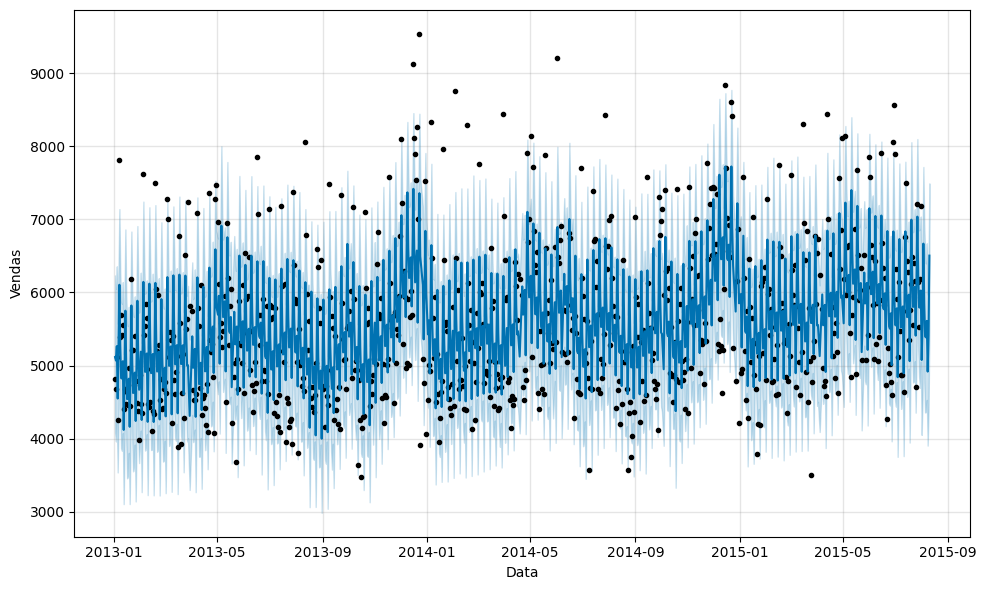

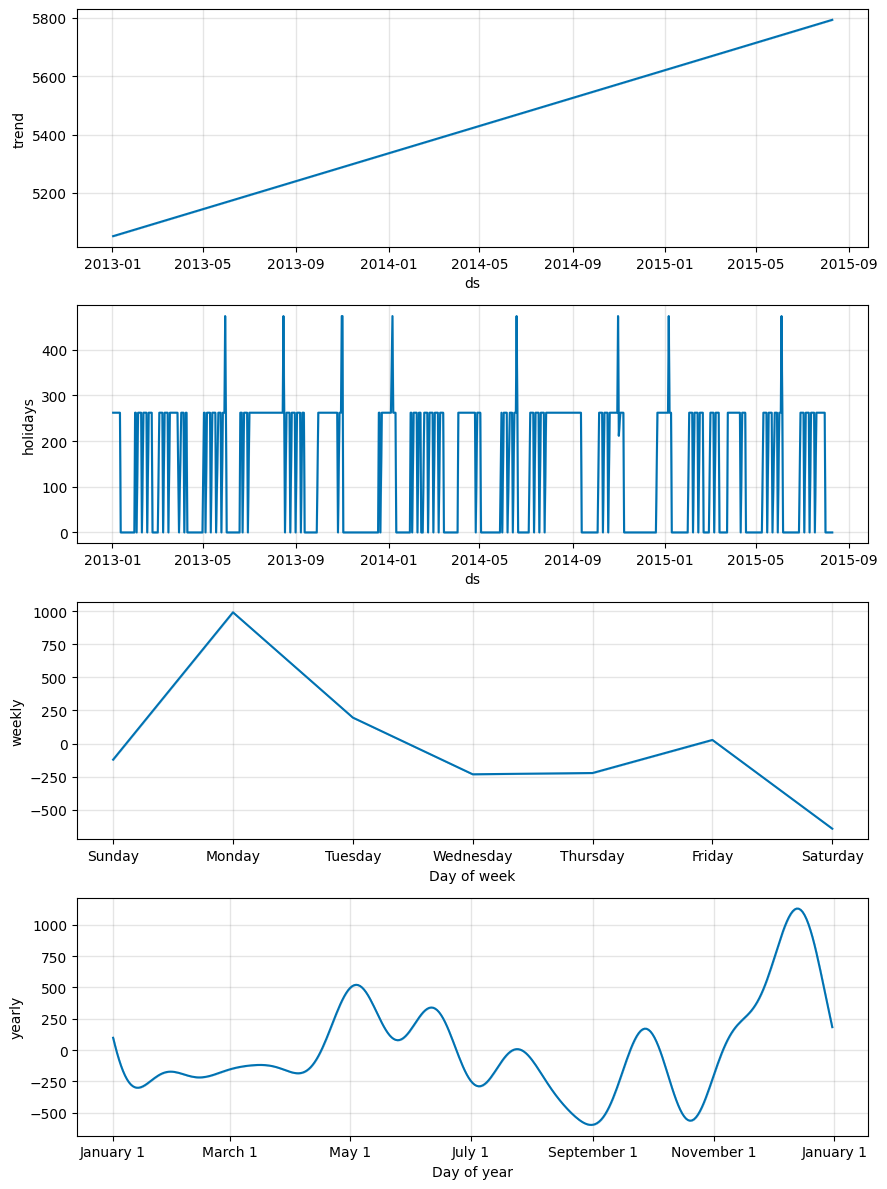

In [75]:
df_origin, df_prediction = sales_prediction(10, sales_train_all_df, school_state_holidays, 10)

In [76]:
df_prediction.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,holidays,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2013-01-02,5051.418288,4085.899058,6232.209262,5051.418288,5051.418288,65.519185,65.519185,65.519185,262.246018,...,-231.166651,-231.166651,-231.166651,34.439818,34.439818,34.439818,0.0,0.0,0.0,5116.937473
1,2013-01-03,5052.199508,3961.922745,6051.979894,5052.199508,5052.199508,16.433113,16.433113,16.433113,262.246018,...,-221.627364,-221.627364,-221.627364,-24.185540,-24.185540,-24.185540,0.0,0.0,0.0,5068.632621
2,2013-01-04,5052.980728,4277.709443,6356.729195,5052.980728,5052.980728,212.514539,212.514539,212.514539,262.246018,...,27.837268,27.837268,27.837268,-77.568747,-77.568747,-77.568747,0.0,0.0,0.0,5265.495267
3,2013-01-05,5053.761948,3538.925915,5573.889605,5053.761948,5053.761948,-504.488386,-504.488386,-504.488386,262.246018,...,-641.383965,-641.383965,-641.383965,-125.350439,-125.350439,-125.350439,0.0,0.0,0.0,4549.273562
4,2013-01-07,5055.324388,5021.710408,7139.228432,5055.324388,5055.324388,1049.599063,1049.599063,1049.599063,262.246018,...,990.623490,990.623490,990.623490,-203.270445,-203.270445,-203.270445,0.0,0.0,0.0,6104.923451
